# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [1]:
##% title Imports
import os
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV, RidgeCV, LassoCV, Lasso
from scipy import stats

from popy.io_tools import *
from popy.behavior_data_tools import *
from popy.neural_data_tools import time_normalize_session, scale_neural_data, remove_low_fr_neurons, remove_trunctuated_neurons
from popy.decoding.decoder_tools import *
from popy.plotting.plotting_tools import *
#from popy.plotting.plot_behavior import show_target_selection 
import popy.config as cfg
from popy.plotting.plot_cortical_grid import plot_on_cortical_grid

# @title Helper Functions
from neural_value_across_target_RUN_all_sessions import project_across_targets, extract_neural_data, load_data_custom

PATH = cfg.PROJECT_PATH_LOCAL


---
# Get data

In [2]:
monkey, session, area = 'ka', '210322', 'MCC'
time_of_interest = [2, 3.5]

neural_dataset = load_data_custom(monkey, session, area=area, n_extra_trials=(0, 0))
neural_dataset = neural_dataset.sortby('trial_id')
neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 35, trial_id: 417, time: 750)
Coordinates: (12/27)
  * unit              (unit) object 'LPFC_03_01' 'LPFC_04_03' ... 'MCC_16_01'
    unit_id_original  (unit) int64 65 8 68 9 16 69 28 ... 46 48 49 53 52 61 58
    channel           (unit) int64 3 4 4 4 5 5 6 6 6 ... 11 12 12 13 13 14 16 16
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '210322' '210322' ... '210322' '210322'
    area              (unit) object 'LPFC' 'LPFC' 'LPFC' ... 'MCC' 'MCC' 'MCC'
    ...                ...
    R_4               (trial_id) float64 0.0 1.0 0.0 0.0 0.0 ... 0.0 1.0 1.0 1.0
    R_5               (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 0.0 1.0 1.0
    R_6               (trial_id) float64 1.0 0.0 0.0 1.0 0.0 ... 1.0 1.0 0.0 1.0
    R_7               (trial_id) float64 0.0 1.0 0.0 0.0 1.0 ... 0.0 1.0 1.0 0.0
    R_8               (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 0.0 1.0 1.0
    fb_sequence       (trial_id) float64 1.0 0.0 4.0 6.0 7.0 ... 7.0 3.0 1.0 0.0
Data variables:
    firing_rates      (trial_id, unit, time) float64 -0.8085 -0.8085 ... -0.7246
Attributes:
    bin_size:  0.01

---
# Section 1: Projection to value subspace

## Define the value subspace

In [3]:
time = neural_dataset.time.data
# round each bin to .1 and remove repetitions
time_reduced = np.unique(np.round(time, 1))
neural_dataset = neural_dataset.sel(time=time_reduced, method='nearest')
neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 35, trial_id: 417, time: 76)
Coordinates: (12/27)
  * unit              (unit) object 'LPFC_03_01' 'LPFC_04_03' ... 'MCC_16_01'
    unit_id_original  (unit) int64 65 8 68 9 16 69 28 ... 46 48 49 53 52 61 58
    channel           (unit) int64 3 4 4 4 5 5 6 6 6 ... 11 12 12 13 13 14 16 16
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '210322' '210322' ... '210322' '210322'
    area              (unit) object 'LPFC' 'LPFC' 'LPFC' ... 'MCC' 'MCC' 'MCC'
    ...                ...
    R_4               (trial_id) float64 0.0 1.0 0.0 0.0 0.0 ... 0.0 1.0 1.0 1.0
    R_5               (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 0.0 1.0 1.0
    R_6               (trial_id) float64 1.0 0.0 0.0 1.0 0.0 ... 1.0 1.0 0.0 1.0
    R_7               (trial_id) float64 0.0 1.0 0.0 0.0 1.0 ... 0.0 1.0 1.0 0.0
    R_8               (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 0.0 1.0 1.0
    fb_sequence       (trial_id) float64 1.0 0.0 4.0 6.0 7.0 ... 7.0 3.0 1.0 0.0
Data variables:
    firing_rates      (trial_id, unit, time) float64 -0.8085 -0.8085 ... -0.7246
Attributes:
    bin_size:  0.01

In [4]:
# project the neural data across targets - from high dimensional space to 3 dimensional space
data_projected = project_across_targets(neural_dataset)
data_projected

0
10
20
30
40
50
60
70


<xarray.DataArray (subspace: 3, trial_id: 417, time: 76)>
array([[[ 1.92974312e-02, -8.36875707e-02,  2.64257840e-01, ...,
         -3.23258929e-02,  6.78071715e-02, -2.74380018e-02],
        [-1.83983039e-01, -8.60327375e-02,  1.42574785e-02, ...,
          7.21324138e-02,  4.46605923e-02, -1.51838491e-01],
        [ 3.41209726e-02,  1.45128778e-01,  1.42902070e-01, ...,
          3.86157717e-01, -4.47104789e-02,  2.83212323e-01],
        ...,
        [ 1.78448014e-02, -6.79103375e-02, -1.56924553e-01, ...,
          2.37894061e-01, -2.96499294e-01,  1.21809130e-02],
        [ 1.39361948e-02, -8.18849987e-02, -1.54113594e-01, ...,
         -9.10630809e-02, -6.03806382e-01, -3.40798842e-01],
        [-3.07553825e-01, -4.42823214e-02, -9.14742651e-01, ...,
          5.61791118e-02,  2.98038401e-02, -2.94351416e-01]],

       [[-1.87063016e-01, -1.90414794e-01, -1.93328745e-01, ...,
          6.53713229e-03, -2.15222003e-01, -1.27168051e-01],
        [-4.20655445e-01, -2.16781209e-01, -8.82612354e-04, ...,
          1.10579116e-03,  2.30150262e-02, -2.74412658e-02],
        [-5.54806978e-02, -4.94865737e-02, -2.48968216e-01, ...,
         -4.86245475e-01, -3.05487092e-01, -6.50925923e-02],
...
        [-1.54282848e-01, -7.92084872e-02, -3.26210741e-02, ...,
          1.41581604e-01, -1.02538161e-01, -1.84870877e-01],
        [-5.50959515e-02,  5.69425532e-02, -2.13914787e-01, ...,
          8.95876327e-02,  2.59820503e-01,  2.04968154e-01],
        [-8.55202991e-02, -8.78959127e-02, -1.29155383e-01, ...,
          1.86144645e-01,  3.92400575e-01,  5.46799512e-02]],

       [[ 2.19542321e-02, -3.13257870e-01, -1.90634936e-01, ...,
          2.01811398e-01,  1.05492529e-01, -1.38888540e-01],
        [-4.07476808e-01, -1.27173336e-01, -1.03601089e-02, ...,
         -1.34707584e-02,  1.73837478e-02, -5.33530937e-02],
        [ 9.01906883e-02,  1.80345535e-01, -1.30048211e-01, ...,
         -9.81473535e-03, -4.32061523e-02, -1.50780484e-01],
        ...,
        [-9.05459256e-02, -3.25574527e-02,  1.36740402e-01, ...,
          1.25317226e-01,  2.06071375e-01, -8.39088162e-02],
        [-1.90611617e-02,  5.35828500e-02,  8.41064826e-02, ...,
          9.57353113e-02,  1.91288615e-01,  1.26794240e-01],
        [ 1.10521350e-01,  5.71073944e-02,  1.61873374e-02, ...,
         -1.50055817e-01,  4.83948054e-02, -1.72482792e-01]]])
Coordinates: (12/21)
  * subspace     (subspace) <U8 'target_1' 'target_2' 'target_3'
  * time         (time) float64 0.0 0.1 0.2 0.3 0.4 0.5 ... 7.1 7.2 7.3 7.4 7.49
    epoch        (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 5.0 5.0 5.0 5.0 5.0
  * trial_id     (trial_id) int64 8 9 10 11 12 13 14 ... 419 420 421 422 423 424
    block_id     (trial_id) int64 0 0 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9 9 9
    best_target  (trial_id) int64 1 1 1 1 1 1 1 1 1 1 1 ... 3 3 3 3 3 3 3 3 3 3
    ...           ...
    R_4          (trial_id) float64 0.0 1.0 0.0 0.0 0.0 ... 1.0 0.0 1.0 1.0 1.0
    R_5          (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 1.0 0.0 1.0 1.0
    R_6          (trial_id) float64 1.0 0.0 0.0 1.0 0.0 ... 0.0 1.0 1.0 0.0 1.0
    R_7          (trial_id) float64 0.0 1.0 0.0 0.0 1.0 ... 1.0 0.0 1.0 1.0 0.0
    R_8          (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 0.0 1.0 0.0 1.0 1.0
    fb_sequence  (trial_id) float64 1.0 0.0 4.0 6.0 7.0 ... 6.0 7.0 3.0 1.0 0.0

In [5]:
# Extract 'neural values' for the specified time range by averaging across time points
neural_values = data_projected.sel(time=slice(*time_of_interest)).mean(dim='time')
neural_values

<xarray.DataArray (subspace: 3, trial_id: 417)>
array([[-7.22423048e-02, -1.08768296e-01,  4.24794740e-02, ...,
         1.46787711e-01, -6.36405546e-02, -2.18736484e-01],
       [-3.59176048e-02, -6.05810332e-02, -1.96007362e-05, ...,
        -1.18081063e-02, -4.10029337e-02, -1.94848195e-01],
       [ 4.91021963e-02, -1.73520525e-01,  1.68257037e-02, ...,
         9.22898089e-03, -6.40805707e-02, -2.50643054e-01]])
Coordinates: (12/19)
  * subspace     (subspace) <U8 'target_1' 'target_2' 'target_3'
  * trial_id     (trial_id) int64 8 9 10 11 12 13 14 ... 419 420 421 422 423 424
    block_id     (trial_id) int64 0 0 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9 9 9
    best_target  (trial_id) int64 1 1 1 1 1 1 1 1 1 1 1 ... 3 3 3 3 3 3 3 3 3 3
    target       (trial_id) float64 3.0 1.0 1.0 1.0 1.0 ... 3.0 3.0 3.0 3.0 2.0
    feedback     (trial_id) float64 0.0 1.0 1.0 1.0 1.0 ... 1.0 0.0 0.0 0.0 1.0
    ...           ...
    R_4          (trial_id) float64 0.0 1.0 0.0 0.0 0.0 ... 1.0 0.0 1.0 1.0 1.0
    R_5          (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 1.0 0.0 1.0 1.0
    R_6          (trial_id) float64 1.0 0.0 0.0 1.0 0.0 ... 0.0 1.0 1.0 0.0 1.0
    R_7          (trial_id) float64 0.0 1.0 0.0 0.0 1.0 ... 1.0 0.0 1.0 1.0 0.0
    R_8          (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 0.0 1.0 0.0 1.0 1.0
    fb_sequence  (trial_id) float64 1.0 0.0 4.0 6.0 7.0 ... 6.0 7.0 3.0 1.0 0.0

In [6]:
# Extract neural values and their change
results_df = extract_neural_data(neural_values, data_projected)
results_df

,trial_id,target,feedback,type,V_neural,V_neural_p1,dV_neural,V_behav,V_behav_p1,dV_behav
0,9,1.0,1,within,-0.108768,0.042479,0.151248,0.06982541018249958,0.4794589559655903,-0.409634
1,9,1.0,1,alter,-0.060581,-0.000020,0.060561,0.06982541018249958,0.4794589559655903,-0.409634
2,9,1.0,1,alter,-0.173521,0.016826,0.190346,0.06982541018249958,0.4794589559655903,-0.409634
3,10,1.0,1,within,0.042479,0.007672,-0.034807,0.4794589559655903,0.6926900295590375,-0.213231
4,10,1.0,1,alter,-0.000020,0.071678,0.071697,0.4794589559655903,0.6926900295590375,-0.213231
...,...,...,...,...,...,...,...,...,...,...
1117,421,3.0,0,alter,0.064137,-0.011808,-0.075945,0.8897626746460694,0.5252860353253535,0.364477
1118,421,3.0,0,within,0.068451,0.009229,-0.059222,0.8897626746460694,0.5252860353253535,0.364477
1119,422,3.0,0,alter,0.146788,-0.063641,-0.210428,0.5252860353253535,0.31011125412468704,0.215175
1120,422,3.0,0,alter,-0.011808,-0.041003,-0.029195,0.5252860353253535,0.31011125412468704,0.215175


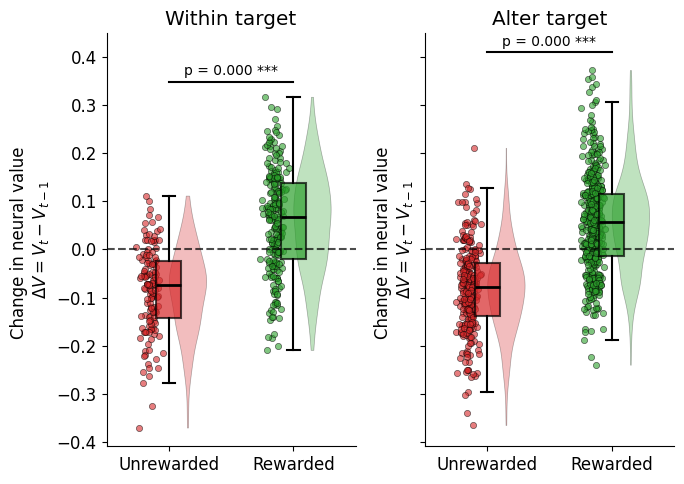

In [10]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# fontsize = 8
plt.rcParams.update({'font.size': 12})

# Create the figure
fig, axs = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

def create_r_style_plot(ax, data, x_col, y_col, palette, title):
    """Create R-style plot with violin, box, and jittered points"""
    
    # Get unique categories
    # sort by x_col
    data = data.copy().sort_values(by=x_col)
    categories = data[x_col].unique()
    x_positions = np.arange(len(categories))
    
    # Create violin plots (distributions) - slightly offset to the right
    violin_parts = ax.violinplot([data.loc[data[x_col] == cat, y_col].values for cat in categories], 
                                positions=x_positions + 0.15, widths=0.3, showmeans=False, 
                                showmedians=False, showextrema=False)
    
    # Color the violin plots
    colors = [palette[str(cat)] for cat in categories]
    for pc, color in zip(violin_parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.3)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)
    
    # Create boxplots - centered
    box_data = [data.loc[data[x_col] == cat, y_col].values for cat in categories]
    bp = ax.boxplot(box_data, positions=x_positions, widths=0.2, patch_artist=True,
                   boxprops=dict(alpha=0.7, linewidth=1.5),
                   showfliers=False,
                   medianprops=dict(color='black', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='black', markersize=3, alpha=0.5))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Add jittered points - slightly offset to the left
    for i, cat in enumerate(categories):
        y_data = data.loc[data[x_col] == cat, y_col].values
        x_jitter = np.random.normal(x_positions[i] - 0.15, 0.04, size=len(y_data))
        ax.scatter(x_jitter, y_data, alpha=0.6, s=20, 
                  color=colors[i], edgecolor='black', linewidth=0.5)
    
    # Perform t-test and add significance
    if len(categories) == 2:
        group1_data = data.loc[data[x_col] == categories[0], y_col]
        group2_data = data.loc[data[x_col] == categories[1], y_col]
        #_, p_value = stats.ttest_ind(group1_data, group2_data)
        U1, p_value = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

        
        # Position for significance bar
        y_max = data[y_col].max()
        y_pos = y_max + 0.1 * abs(y_max)
        
        # Add significance annotation
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'n.s.'
        
        # Add the bar and text for p-value
        ax.plot([0, 1], [y_pos, y_pos], '-k', lw=1.5)
        ax.text(0.5, y_pos + 0.02 * abs(y_max), f'p = {p_value:.3f} {significance}', 
                ha='center', va='bottom', fontsize=10)
    
    # Formatting
    ax.axhline(0, linestyle='--', alpha=0.7, color='black')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Unrewarded', 'Rewarded'])
    ax.set_ylabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$')
    ax.set_xlabel('')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return ax

# Create the plots
palette = {'0': 'tab:red', '1': 'tab:green'}

# Within target plot
create_r_style_plot(axs[0], 
                   results_df.loc[results_df['type'] == 'within'], 
                   'feedback', 'dV_neural', palette, 'Within target')

# Alter target plot
create_r_style_plot(axs[1], 
                   results_df.loc[results_df['type'] == 'alter'], 
                   'feedback', 'dV_neural', palette, 'Alter target')

plt.tight_layout()

# save svg
#plt.savefig('figs/dV_neural_behav_rstyle.svg', format='svg', bbox_inches='tight')